In [ ]:
import warnings

warnings.filterwarnings("ignore")
import torch

import pandas as pd
import numpy as np
import scanpy as sc
import os
import yaml
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['R_HOME'] = r"E:\R-4.5.1"
os.environ['PATH'] = r"E:\R-4.5.1\bin\x64;" + os.environ['PATH']
from sklearn.decomposition import PCA

# %%
import sys
sys.path.append(r"E:\pycharm\project4")
import MACWT as TOOLS

In [ ]:
def load_data(config, proj_name):
    # %%
    data_root = Path('E:\pycharm\project3\datasets\DLPFC')
    adata = sc.read_visium(data_root / proj_name, count_file=proj_name + "_filtered_feature_bc_matrix.h5")
    adata.var_names_make_unique()

    ##### Load layer_guess label, if have
    truth_path = "E:\\pycharm\\PythonProject2\\datasets\\DLPFC\\" + proj_name + '/' + proj_name + '_truth.txt'
    Ann_df = pd.read_csv(truth_path, sep='\t', header=None, index_col=0)
    Ann_df.columns = ['Ground Truth']
    adata.obs['layer_guess'] = Ann_df.loc[adata.obs_names, 'Ground Truth']

    edge_index = TOOLS.graph_construction(adata, config['data']['k_cutoff'])

    adata.layers['count'] = adata.X.toarray()
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=config['data']['top_genes'])
    adata = adata[:, adata.var['highly_variable'] == True]
    sc.pp.scale(adata)

    adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
    adata.obsm['X_pca'] = adata_X

    return adata, edge_index

In [ ]:
def train_one(proj_name, adata, edge_index, config, clusType="mclust"):
    num_clusters = 5 if proj_name in ['151669', '151670', '151671', '151672'] else 7
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    net = TOOLS.SC_pipeline(adata, edge_index=edge_index, num_clusters=num_clusters, device=device, config=config, imputation=False)
    net.trian()
    enc_rep, recon = net.process()
    adata.obsm['latent'] = enc_rep
    adata.obsm['recon'] = recon
    adata.obs[clusType] = TOOLS.clustering(z=enc_rep, n_clust=num_clusters, num_seed=1, method=clusType)
    sub_adata = adata[~pd.isnull(adata.obs['layer_guess'])]
    ARI, ACC, DIS = TOOLS.get_metrics(sub_adata, 'layer_guess', clusType)
    return ARI, ACC, DIS, adata, net

In [ ]:
with open('E:\pycharm\project4\Config\DLPFC.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

In [ ]:
tissue_name = "151675"
adata, edge_index = load_data(config, tissue_name)

In [ ]:
ARI, ACC, DIS, adata, net = train_one(tissue_name, adata, edge_index, config)

# # ===== 小波模块特征可视化 =====
# import sys
# sys.path.insert(0, r"E:\学习\研\1")
# from wavelet_viz import run_wavelet_visualization

# run_wavelet_visualization(
#     model=net.model,
#     X_tensor=net.X,
#     edge_index=net.edge_index,
#     adata=adata,
#     true_label_key='layer_guess',
#     n_clusters=7,
#     slice_name=tissue_name,
#     save_dir=r'E:\学习\研\1\MACWT2026_images',
# )





In [ ]:
spot_size = 140
sc.pl.spatial(adata, color=['layer_guess'], spot_size=spot_size, legend_loc=None,
              title='layer_guess', show=True,
              )

In [ ]:
maps = {'7': 'Layer_1', '5': 'Layer_2', '6': 'Layer_3', '1': 'Layer_4', '2': 'Layer_5', '3': 'Layer_6', '4': 'WM'}
values = [maps[value] for value in adata.obs["mclust"]]
data = {'cluster': values}
df = pd.DataFrame(data, index=adata.obs["mclust"].index)
adata.obs['domain'] = df

sc.pl.spatial(
    adata,
    color=['domain'],
    spot_size=spot_size,
    legend_loc=None,
    title=f"{tissue_name}\nARI:{ARI :.3f} ACC:{ACC :.3f}",
    alpha_img=0,
    na_color='white',
    show=True,
    
)


In [ ]:

sc.pp.neighbors(adata, n_neighbors=12, n_pcs=16, use_rep="latent")
sc.tl.umap(adata)
sc.tl.paga(adata, groups='domain')
sc.pl.paga_compare(adata, legend_fontsize=25, frameon=False, size=spot_size, title=' ', legend_fontoutline=1, show=True)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu
import seaborn as sns

# 假设前面的代码已经运行，adata 中已包含 'domain' 列（映射后的真实层名）
# 并且 scanpy 已导入为 sc

# ==================== 生物学标记基因验证 ====================
marker_genes = ['PCP4', 'MOBP', 'HPCAL1', 'KRT17']
valid_markers = [g for g in marker_genes if g in adata.var_names]
print(f"有效标记基因: {valid_markers}")

if len(valid_markers) == 0:
    raise ValueError("未找到任何标记基因，请检查基因名称或调整高变基因筛选阈值。")

# 1. 标记基因的空间表达散点图
for gene in valid_markers:
    sc.pl.spatial(
        adata,
        color=gene,
        cmap='Reds',
        spot_size=140,
        title=f'{gene} expression',
        alpha_img=1.0,
        show=True,
    )

# 2. 标记基因在各 domain 中的小提琴图（不带统计检验的概览图）
for gene in valid_markers:
    sc.pl.violin(
        adata,
        keys=gene,
        groupby='domain',
        rotation=45,
        show=False,
    )
    plt.title(f'{gene} per MACWT domain')
    plt.tight_layout()
    plt.show()

# 3. 显著性检验：每个基因在其预期富集域的特异性检验
# 根据已知文献预设目标域（若您的映射不同，请修改此处字典）
target_domains = {
    'PCP4': 'Layer_5',
    'MOBP': 'Layer_6',      # 或者 'WM'，视您的映射而定
    'HPCAL1': 'Layer_2',    # 或 'Layer_3'，视实际分层
    'KRT17': 'Layer_6',     # 常与深层/白质相关，可调整
}

for gene in valid_markers:
    if gene not in target_domains:
        print(f"跳过 {gene}：未指定目标域")
        continue
    target = target_domains[gene]
    domain_col = adata.obs['domain']
    
    # 提取表达值（兼容稀疏矩阵）
    if hasattr(adata[:, gene].X, 'toarray'):
        expr = adata[:, gene].X.toarray().flatten()
    else:
        expr = adata[:, gene].X.flatten()
    
    mask = domain_col == target
    if mask.sum() == 0:
        print(f"未检测到 {target} 域，无法进行 {gene} 富集检验。")
        continue
    
    target_expr = expr[mask]
    other_expr = expr[~mask]
    stat, p = mannwhitneyu(target_expr, other_expr, alternative='greater')
    print(f"{gene} 在 {target} 与非 {target} 的 Mann-Whitney U 检验: p = {p:.2e}")
    
    # 绘制带 p 值标注的小提琴图
    plt.figure(figsize=(6, 4))
    df_plot = pd.DataFrame({'Domain': domain_col, gene: expr})
    sns.violinplot(data=df_plot, x='Domain', y=gene, order=sorted(df_plot['Domain'].unique()))
    plt.title(f'{gene} enrichment in {target} (p = {p:.2e})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("生物学标记基因验证完成。")

In [ ]:
# ==================== Layer 5 GO 富集（保存到文件）====================
import gseapy as gp
import matplotlib.pyplot as plt

save_dir = r"E:\学习\研\1\MACWT2026_images"

# 重新获取 Layer 5 的 DEGs
result = sc.get.rank_genes_groups_df(adata, group='Layer_5')
result = result[(result['logfoldchanges'] > 0.25) & (result['pvals_adj'] < 0.1)]
genes_layer5 = result.sort_values('logfoldchanges', ascending=False)['names'].tolist()
print(f"Layer 5: {len(genes_layer5)} DEGs")

# GO 富集
enr = gp.enrichr(
    gene_list=genes_layer5,
    gene_sets='GO_Biological_Process_2021',
    organism='Human',
    outdir=None,
)

# 打印结果
top = enr.results.head(10)
for _, row in top.iterrows():
    print(f"  {row['Term']}  p={row['Adjusted P-value']:.2e}")

# 保存气泡图
fig, ax = plt.subplots(figsize=(10, 5))
gp.barplot(top, title='Layer 5 GO Biological Process', ax=ax)
plt.tight_layout()
plt.savefig(f"{save_dir}/Layer5_GO_BP.pdf", dpi=200, bbox_inches='tight')
plt.savefig(f"{save_dir}/Layer5_GO_BP.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"图片已保存到 {save_dir}")


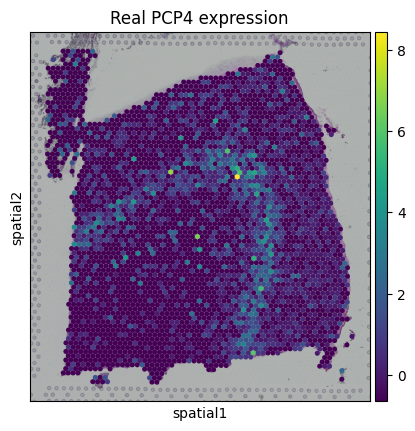

In [13]:
sc.pl.spatial(
    adata,
    color=['PCP4'],  # 直接用真实基因名
    spot_size=spot_size,
    title="Real PCP4 expression"
)

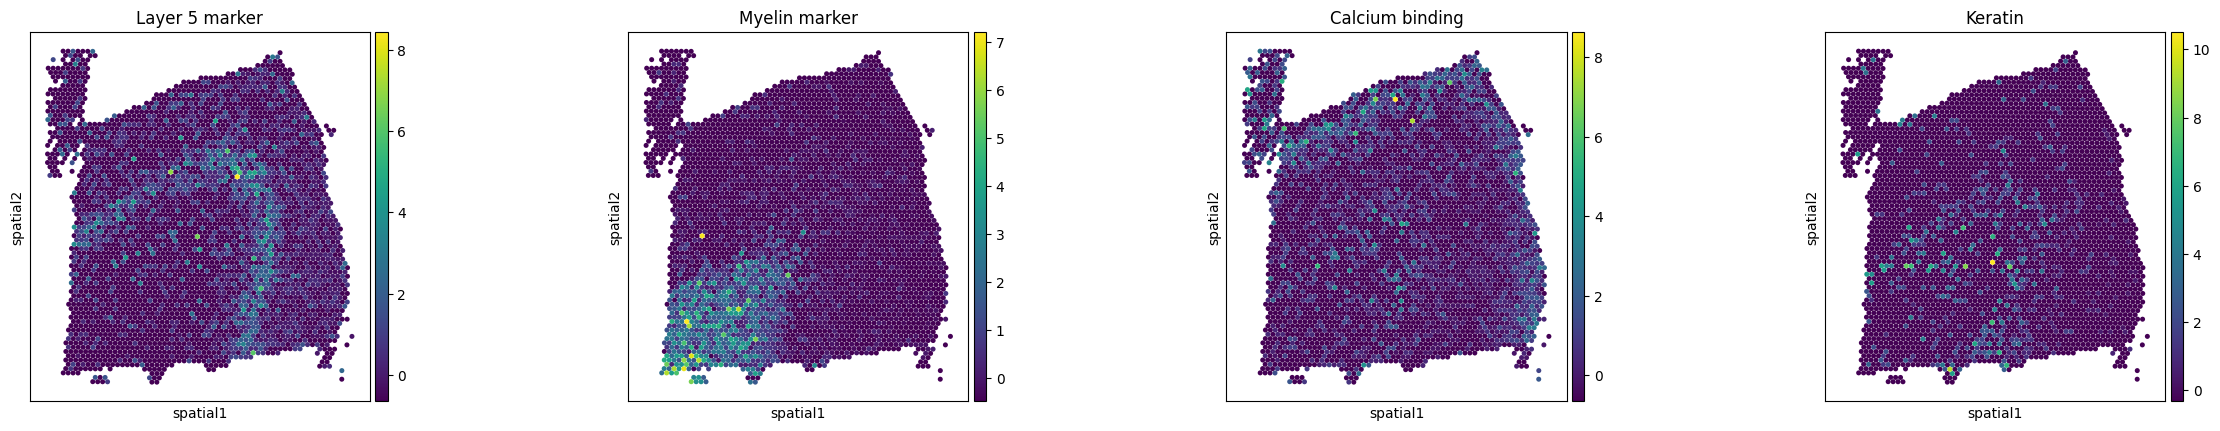

In [13]:
gene_list = ['PCP4', 'MOBP', 'HPCAL1', 'KRT17']
custom_titles = ['Layer 5 marker', 'Myelin marker', 'Calcium binding', 'Keratin']

# 这里 custom_titles 和 gene_list 长度都是 4
sc.pl.spatial(
    adata,
    color=gene_list,
    title=custom_titles,   # 长度必须等于 len(gene_list)
    spot_size=spot_size,
    alpha_img=0,
    ncols=4,
    show=True
)